In [1]:
import os 
os.chdir("/nfshome/narjis/")

In [2]:
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

In [3]:
hdf5_path = "EV_brightfield.hdf5"
idx = 0
with h5py.File(hdf5_path, "r") as f:
    image_dataset_size = f["image_patches"].shape[0]
    img = f["image_patches"][idx]
    mask = f["mask_patches"][idx]

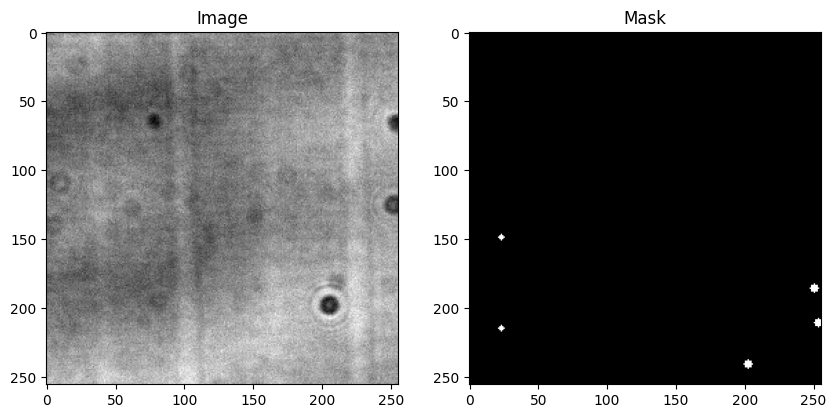

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img[0], cmap="gray")
ax[0].set_title("Image")
ax[1].imshow(mask[0], cmap="gray")
ax[1].set_title("Mask")
plt.show()

In [5]:
def to_8bit(image):
    """
    Convert a 16-bit image to an 8-bit image.
    """
    # Normalize the image to the range [0, 255]
    normalized_image = (image / 65535.0) * 255.0
    # Convert to uint8
    return normalized_image.astype(np.uint8)

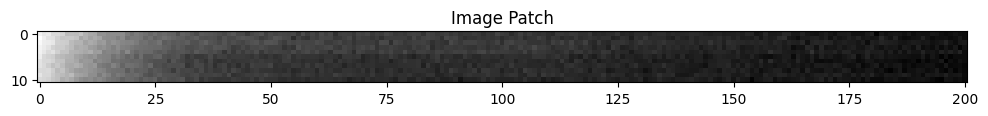

In [6]:
from skimage import measure
import numpy as np

# Option to choose specific index or the region with the biggest area
choose_biggest_area = False  # Set to False to choose a specific index
idx = 4  # Only used if choose_biggest_area is False

# Label connected regions in the mask
labeled_mask = measure.label(mask[0])
normalized_img = to_8bit(img)
# Get properties of labeled regions
regions = measure.regionprops(labeled_mask)

if regions:
    if choose_biggest_area:
        # Find the region with the biggest area
        region = max(regions, key=lambda r: r.area)
    else:
        # Select the region by index
        region = regions[idx]
    # Get bounding box of the region
    min_row, min_col, max_row, max_col = region.bbox

    # Extract a small image patch from img using the bounding box
    tolerance = 2

    image_patch = normalized_img[:, max(0, min_row-tolerance):min(img.shape[1], max_row+tolerance), max(0, min_col-tolerance):min(img.shape[2], max_col+tolerance)]
else:
    print("No labeled regions found in the mask.")

avg_img = np.mean(image_patch, axis=1)
avg_img = avg_img.transpose(1,0)
# Display the image patch
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(avg_img, cmap="gray")
ax.set_title("Image Patch")
plt.show()

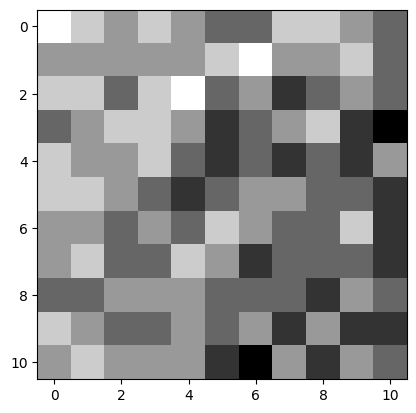

In [8]:
# plt.imshow(to_8bit(image_patch[0]), cmap="gray")
plt.imshow(image_patch[10], cmap="gray")
plt.show()

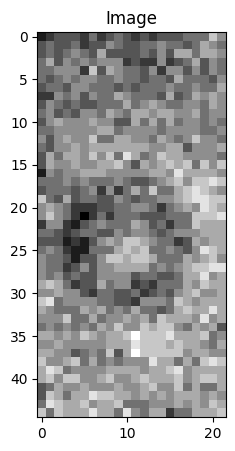

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(to_8bit(img[0,85:130,0:22]), cmap="gray")
ax.set_title("Image")
plt.show()

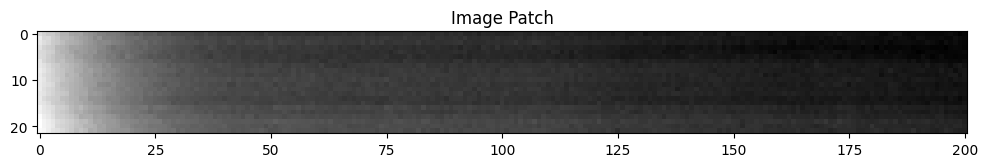

In [10]:
ev_p = img[:,85:130,0:22]
ev_p = np.mean(ev_p, axis=1)
ev_p = ev_p.transpose(1,0)
# Display the image patch
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(ev_p, cmap="gray")
ax.set_title("Image Patch")
plt.show()

In [25]:
def process_hdf5_images(hdf5_path):
    """
    Open the HDF5 file, load all images, extract regions, average over the x-axis,
    transpose to (1, 0), resize the 0-axis to 16 by padding equally at the top and bottom,
    and store everything in one array.

    Parameters:
        hdf5_path (str): Path to the HDF5 file.

    Returns:
        numpy.ndarray: Processed array containing all resized image regions.
    """
    with h5py.File(hdf5_path, "r") as f:
        # Load all images
        images = f["image_patches"][:]
        masks = f["mask_patches"][:]
        
        processed_images = []

        for img, mask in zip(images, masks):
            # Normalize the image
            normalized_img = img

            # Label connected regions in the mask
            labeled_mask = measure.label(mask[0])

            # Get properties of labeled regions
            regions = measure.regionprops(labeled_mask)

            for region in regions:
                # Get bounding box of the region
                min_row, min_col, max_row, max_col = region.bbox

                # Extract a small image patch from img using the bounding box
                tolerance = 2
                image_patch = normalized_img[:, 
                                             max(0, min_row - tolerance):min(img.shape[1], max_row + tolerance), 
                                             max(0, min_col - tolerance):min(img.shape[2], max_col + tolerance)]

                # Average over the x-axis
                avg_img = np.mean(image_patch, axis=1)

                # Transpose to (1, 0)
                avg_img = avg_img.transpose(1, 0)

                # Resize the 0-axis to 16 by padding equally at the top and bottom
                if avg_img.shape[0] < 16:
                    total_padding = 16 - avg_img.shape[0]
                    padding_top = total_padding // 2
                    padding_bottom = total_padding - padding_top
                    padding = np.tile(avg_img[0], (padding_top, 1))
                    avg_img = np.vstack((padding, avg_img))
                    padding = np.tile(avg_img[-1], (padding_bottom, 1))
                    avg_img = np.vstack((avg_img, padding))
                elif avg_img.shape[0] > 16:
                    avg_img = avg_img[:16]

                # Add to the processed images list
                processed_images.append(avg_img)

        # Combine all processed images into one array
        processed_array = np.array(processed_images)
        return processed_array

In [26]:
ev_particles=process_hdf5_images(hdf5_path)

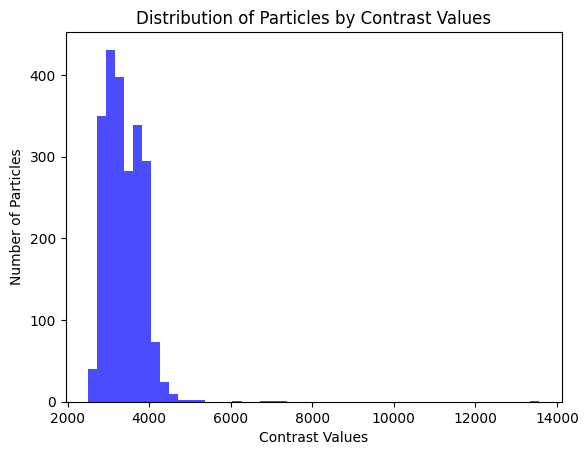

In [51]:
# Calculate contrast for each particle in ev_particles
contrast_values = [np.max(particle) - np.min(particle) for particle in ev_particles]

# Flatten the contrast values to create a single array
# flattened_contrast = np.concatenate(contrast_values)

# Plot the histogram
plt.hist(contrast_values, bins=50, color='blue', alpha=0.7)
plt.xlabel("Contrast Values")
plt.ylabel("Number of Particles")
plt.title("Distribution of Particles by Contrast Values")
plt.show()

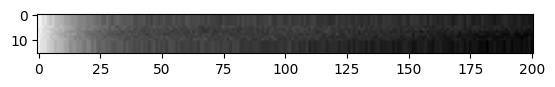

In [29]:
plt.imshow(ev_particles[2], cmap="gray")

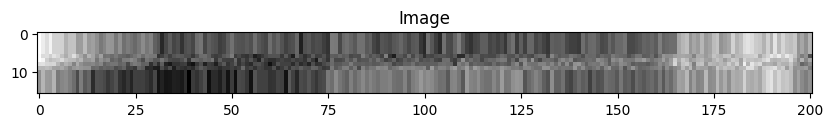

In [52]:
hdf5_path = "Downloads/brightfield_particles.hdf5"
idx = 3
with h5py.File(hdf5_path, "r") as f:
    image_dataset_size = f["data"].shape[0]
    img_ = f["data"][idx]
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img_, cmap="gray")
ax.set_title("Image")
plt.show()

In [ ]:
from src.inference.inference import SegInference
import torch
import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda:0"
experiment_path = "experiments/runs/U_Net_Brightfield_EV_seg_2025-05-13_15-10-00/best_model.pth"
seginf = SegInference(experiment_path,DEVICE)